# **ANALYSIS & PREDICTION OF WALMART SALES** #

## **PROBLEM STATEMENT** ##

**DESCRIPTION**

One of the leading retail stores in the US, Walmart, would like to predict the sales and demand accurately. There are certain events and holidays which impact sales on each day. There are sales data available for 45 stores of Walmart. The business is facing a challenge due to unforeseen demands and runs out of stock some times, due to the inappropriate machine learning algorithm. An 

ideal ML algorithm will predict demand accurately and ingest factors like economic conditions including CPI, Unemployment Index, etc.

Walmart runs several promotional markdown events throughout the year. These markdowns precede prominent holidays, the four largest of all, which are the Super Bowl, Labour Day, Thanksgiving, and Christmas. The weeks including these holidays are weighted five times higher in the evaluation than non-holiday weeks. Part of the challenge presented by this competition is modeling the effects of markdowns on these holiday weeks in the absence of complete/ideal historical data. Historical sales data for 45 Walmart stores located in different regions are available.


**DATA DESCRIPTION**

This is the historical data which covers sales from 2010-02-05 to 2012-11-01, in the file Walmart_Store_sales. Within this file you will find the following fields:

Store - the store number
Date - the week of sales
Weekly_Sales -  sales for the given store
Holiday_Flag - whether the week is a special holiday week 1 – Holiday week 0 – Non-holiday week
Temperature - Temperature on the day of sale
Fuel_Price - Cost of fuel in the region
CPI – Prevailing consumer price index
Unemployment - Prevailing unemployment rate

Holiday Events
Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
Labour Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

 
**ANALYSIS TASKS**

1. Which store has maximum sales

2. Which store has maximum standard deviation i.e., the sales vary a lot. Also, find out the coefficient of mean to standard deviation

3. Which store/s has good quarterly growth rate in Q3’2012

4. Some holidays have a negative impact on sales. Find out holidays which have higher sales than the mean sales in non-holiday season for all stores together

5. Provide a monthly and semester view of sales in units and give insights

 

**STATISTICAL MODEL**

For Store 1 – Build  prediction models to forecast demand

Linear Regression – Utilize variables like date and restructure dates as 1 for 5 Feb 2010 (starting from the earliest date in order). Hypothesize if CPI, unemployment, and fuel price have any impact on sales.

Change dates into days by creating new variable.

Select the model which gives best accuracy 

# **PROJECT** 

In [ ]:
#getting work directory
getwd()

In [ ]:
#uploading data
data1 <- read.csv("../input/retail-analysis-with-walmart-sales-data/WALMART_SALES_DATA.csv")

In [ ]:
#Calling libraries
library("dplyr") #Calling dplyr function for data manipulation 
library("ggplot2") # for data visualisation
library("scales") #for change of scales in data visualisation
library("zoo")
library("tidyverse")
library("tidyr")
library("lubridate")
library(car) #Companion to Applied Regression for Regression Visualisations
require(stats)
library(corrplot)
library(caTools)
library(MLmetrics)
library("repr")

## Understanding Data ##

In [ ]:
head(data1)

In [ ]:
#Data Exploration  - dimensions
dim(data1)

In [ ]:
#Data Exploration  - class
class(data1)

In [ ]:
#Data Exploration -structure
str(data1)

In [ ]:
#Data Exploration - summary
summary(data1)

In [ ]:
#Data Exploration - tables
table(data1$Store)

table(data1$Holiday_Flag)

In [ ]:
#Checking NA values 
colSums(is.na(data1)) #Observed no NA values

In [ ]:
#Checking Duplicate Values
all(duplicated(data1) == TRUE)
#observed no duplicate values

### **Summarisation of Data** ###
Exploratory Data Analysis of Retail Analysis with Walmart Data 
* Industry:  Retail Industry
* This data is about different stores weekly sales and consists possible influence factors CPI, Un Employment Rate Fuel Price, Holiday Type  that may affect sales
* Dimensions: 6435 observations, 8 variables.
* Missing Data / Null Values: No
* Duplicated Values:   No
* Structure: Data frame


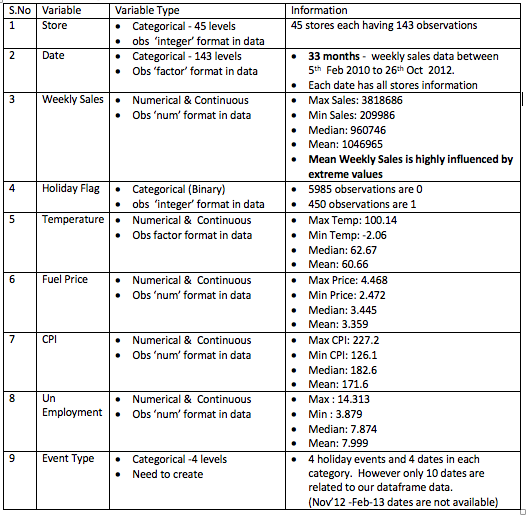

## **ANALYSIS TASKS** ##

## Which Store has maximum sales? ##

In [ ]:
#Aggregating data by 'Store' and Finding sum of 'Weekly_Sales' 
Store_Sales<- aggregate(Weekly_Sales ~ Store, data = data1, sum)

#Changing column name of sales 
colnames(Store_Sales)[2] <- "Total_Sales_by_Store"

#Finding out Store with highest Sales 

Store_Sales <-arrange(Store_Sales, desc(Total_Sales_by_Store)) #Arranged Stores based on Sales in descending order
Store_Sales[1,] #Choosing the first store that comes in this order

In [ ]:
#Printing the output
print(paste('Store no.', Store_Sales[1,]$Store,
'has the maximum sales and the value is = ', Store_Sales[1,]$Total_Sales_by_Store))

In [ ]:
# Converting Store column into factor so that order won't change for graph 
Store_Sales$Store <- as.character(Store_Sales$Store)
Store_Sales$Store <- factor(Store_Sales$Store, levels=unique(Store_Sales$Store))


#Plotting Store vs TotalSales


options(repr.plot.width = 14, repr.plot.height = 8)

a<-ggplot(data=Store_Sales, aes(x=Store, y=Total_Sales_by_Store)) + geom_bar(stat="identity",fill="steelblue") +
theme(axis.text.x = element_text(angle = 90,vjust = 0.5, hjust=0.5))+ scale_x_discrete(breaks = data1$Store)+
scale_y_continuous(labels = label_number(suffix = " M", scale = 1e-6))+ ggtitle('Store vs Sales')+
theme(plot.title = element_text(hjust = 0.5))+
xlab("Stores") + ylab("Total Sales")
a

### **Insights:** ###
* Store 20 has the maximum sales and the value is 301397792.46 (i.e., 301.39M)
* Store 4  is the second largest store in terms of sales and the value is 299543953 (i.e., 299.54M)
* Store 33 has the least sales 37160222 (i.e., 37.16M)


## Which store has maximum standard deviation i.e., the sales vary a lot. Also, find out the coefficient of mean to standard deviation ##

In [ ]:
#Aggregating data by 'Store' and Finding Standard Deviation of 'Weekly_Sales' 
Store_Sales_Variation<-summarise(group_by(data1,Store),sd(Weekly_Sales), mean(Weekly_Sales))

#Changing column names
colnames(Store_Sales_Variation)[2] <- "StandardDeviation_Sales_by_Store"
colnames(Store_Sales_Variation)[3] <- "Mean_Sales_by_Store"

#Creating Coefficient of Variation for Sales by Store in Store_Sales_Variation dataframe 
Store_Sales_Variation<- mutate(Store_Sales_Variation,CV_Sales_by_Store = (StandardDeviation_Sales_by_Store/Mean_Sales_by_Store)*100)

In [ ]:
#------Finding Store with highest Standard deviation-------#

#Finding out the row with highest standard deviation 
Store_Sales_Variation[which.max(Store_Sales_Variation$StandardDeviation_Sales_by_Store), ]

#Storing store number with max std deviation value
store_sales_max_std <- Store_Sales_Variation[which.max(Store_Sales_Variation$StandardDeviation_Sales_by_Store), ]$Store

#Storing max std deviation value
max_sd <- Store_Sales_Variation[which.max(Store_Sales_Variation$StandardDeviation_Sales_by_Store), ]$StandardDeviation_Sales_by_Store

#Storing CV value for max std deviation
CV_max_sd <- Store_Sales_Variation[which.max(Store_Sales_Variation$StandardDeviation_Sales_by_Store), ]$CV_Sales_by_Store

#Store with highest variation in Sales - Store 14 & Standard Deviation - 317570, C.V - 5.7137

#printing the output
print(paste('Store no. ', store_sales_max_std,
'has the maximum standard deviation of ', max_sd, 'Coefficient of Variation = ',CV_max_sd ))

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 8)

#Density Plot for Store 14
Store_14 <- data1[data1$Store == 14, ]
p <- ggplot(Store_14, aes(x=Weekly_Sales)) + geom_density(color="darkblue", fill="lightblue",alpha=0.2)+
geom_vline(aes(xintercept= mean(Weekly_Sales)),color="steelblue", linetype="dashed", size=1)+
theme(axis.text.x = element_text(vjust = 0.5, hjust=0.5))+ scale_x_continuous(labels = label_number(suffix = " M", scale = 1e-6))+ ggtitle('Store 14 Sales distribution')+
theme(plot.title = element_text(hjust = 0.5))+
xlab("Weekly Sales") + ylab("Density")
p

## **Insights:** ##
* Store 14 has highest  SD 317569.95 (317.5K) & CV = 15.714
* Store 14 sales are right skewed  i.e, It  had very high sales in few weeks which resulted in increasing of Standard deviation
* Inspite of having highest Standard deviation Store 14  CV is relatively low

## Which store/s has good quarterly growth rate in Q3’2012 ##

In [ ]:
#Creating new dataframe to do alterations 
data2<-data1

#Creating a month- year column in data2 
data2$month_Year = substr(data2$Date, 4, 10)

#Subsetting Q3-2012 data (i.e, 07-2012,08-2012,09-2012), Q2-2012 data (i.e, 04-2012,05- 2012,06-2012)
Q3_2012 <- filter(data2,month_Year == "07-2012" | month_Year== "08-2012" | month_Year== "09-2012")
Q2_2012 <- filter(data2,month_Year == "04-2012" | month_Year== "05-2012" | month_Year== "06-2012")

#Aggregating sales by store for Q3-2012 
Q3_2012_Sales<-summarise(group_by(Q3_2012,Store),sum(Weekly_Sales))

#Changing column names
colnames(Q3_2012_Sales)[2] <- "Q3_2012_Sales_by_Store"

#Aggregating sales by store each Q2-2012 
Q2_2012_Sales<-summarise(group_by(Q2_2012,Store),sum(Weekly_Sales))

#Changing column names
colnames(Q2_2012_Sales)[2] <- "Q2_2012_Sales_by_Store"

#merging two quarters data by store
Q3_2012_Growthrate <- merge ( Q2_2012_Sales , Q3_2012_Sales , by = 'Store')

#Creating Growth rate column for Sales by Store in the above dataframe 
Q3_2012_Growthrate <- mutate(Q3_2012_Growthrate, Growth_Rate = ((Q3_2012_Sales_by_Store - Q2_2012_Sales_by_Store)*100) / Q2_2012_Sales_by_Store)

#Creating only positive growth rates
positive_growthrate <- filter(Q3_2012_Growthrate, Growth_Rate > 0 ) 
positive_growthrate<-arrange(positive_growthrate, desc(Growth_Rate)) 
View(positive_growthrate)
a<- positive_growthrate$Store

#printing the output
print(paste(c('The positive growth rate Stores are', a),collapse=" " )) 
print(paste('Store',positive_growthrate[1,1], 'has highest growth rate & it is',positive_growthrate[1,4]))

# Store 7 -13.33% , Store 16 - 8.49% , Store 35 - 4.47% and 7 more stores with positive growth rates.

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 8)

# Visual representation of growth rates
c<-ggplot(data=Q3_2012_Growthrate, aes(x=Store, y=Growth_Rate)) +geom_bar(stat ="identity",fill="steelblue")+
ggtitle('Growth rates of Q3- 2012')+
theme(plot.title = element_text(hjust = 0.5))+
xlab("Stores") + ylab("Growth rate(%)") +
scale_x_continuous("Stores", labels = as.character(Q3_2012_Growthrate$Store), breaks =
Q3_2012_Growthrate$Store)+
theme(axis.text.x = element_text(angle = 90,vjust = 0.5, hjust=0.5))
c

## **Insights:** ##
* Store 7 has highest growth rate 13.33%, Store 16 second highest growth rate 8.49%, Store 35 third highest growth rate 4.47%
* It is observed that seven other stores has positive growth rates and they are 26,39,41,44,24,40,23
* Store 14 has highest negative growth rate.


# Some holidays have a negative impact on sales. Find out holidays which have higher sales than the mean sales in non-holiday season for all stores together #

In [ ]:
#Creating Holidays Data dataframe
Holiday_date <- c("12-02-2010", "11-02-2011", "10-02-2012", "08-02-2013","10-09-2010", "09-09-2011", "07-09-2012", "06-09-2013","26-11-2010", "25-11-2011", "23-11-2012", "29- 11-2013","31-12-2010", "30-12-2011", "28-12-2012", "27-12-2013")
Events <-c(rep("Super Bowl", 4), rep("Labour Day", 4),rep("Thanksgiving", 4), rep("Christmas", 4))
Holidays_Data <- data.frame(Events,Holiday_date)

#merging both dataframes
data3<-merge(data1,Holidays_Data, by.x= "Date", by.y="Holiday_date", all.x = TRUE)

#Replacing null values in Event with No_Holiday 
data3$Events = as.character(data3$Events) 
data3$Events[is.na(data3$Events)]= "No_Holiday" 
head(data3)

In [ ]:
#Creating dataframe the mean of sales for No_Holiday and also mean of sales for different events
Holiday_Sales<-aggregate(Weekly_Sales ~ Events, data = data3, mean)
#Changing column names
colnames(Holiday_Sales)[2] <- "Mean_Sales_by_Event_Type"
View(Holiday_Sales)

# Christmas and Labour Day has negative impact on sales where as Thanks giving and Super Bowl has positive impact on sales

In [ ]:
# checking negative impact based on holiday date and non- holiday date
#Filtering holiday dates and finding mean of Weekly Sales 
Holiday_date <- filter(data3,Holiday_Flag ==1)
Holiday_Date_Sales<-summarise(group_by(Holiday_date,Date),mean(Weekly_Sales))

#Caluclating mean of Weekly Sales for non holidays
mean_non_holiday_sales <- mean(filter(data3,Holiday_Flag ==0)$Weekly_Sales) 
Holiday_Date_Sales$higher_than_non_holiday <- Holiday_Date_Sales[,2] > mean_non_holiday_sales
View(Holiday_Date_Sales)

## **Insights:** ##
* Super Bowl, Thanks giving, Labour day  has higher sales than mean sales of a Non Holiday and creating positive impact on sales.
* 9th Sept 2011, 10th Sept 2010 ,30th Dec 2011, 31st Dec 2010 were the dates which created negative impact on sales
* All the dates related to Christmas have low sales than mean, whereas all the dates related to Super Bowl, Thanks giving have high sales than mean. 
* It is interesting to note that  Labour Day has overall positive impact on sales inspite of having two days days below mean value.

In [ ]:
weekly_sales <- aggregate(Weekly_Sales~Date, data=data1,mean)
weekly_sales$Date <-as.Date(weekly_sales$Date, "%d-%m-%Y")
weekly_sales <-arrange(weekly_sales,Date)
weekly_sales$Date <-factor(weekly_sales$Date)


options(repr.plot.width = 14, repr.plot.height = 8)

# plotting weekly mean sales
d <- ggplot(data=weekly_sales, aes(x=Date, y=Weekly_Sales, group=1)) +
geom_line(color="steelblue")+
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_x_discrete(breaks = levels(weekly_sales$Date)[c(T, rep(F, 9))])+
scale_y_continuous(labels = label_number(suffix = " M", scale = 1e-6))+
  theme(plot.title = element_text(hjust = 0.5))+
  xlab("Week") + ylab("Mean Sales of Week")

In [ ]:
#Plotting Christmas
d +ggtitle('CHRISTMAS')+
  geom_point(aes(x = factor("2010-12-31"), y = 898500.4), color = "red", size = 2) +
  geom_point(aes(x = factor("2011-12-30"), y = 1023165.8), color = "red", size = 2) +
  geom_hline(aes(yintercept = mean_non_holiday_sales), linetype="dashed")

#Plotting Labourday
d + ggtitle('LABOUR DAY')+
  geom_point(aes(x = factor("2010-09-10"), y = 1014097.7), color = "deeppink", size = 2) +
  geom_point(aes(x = factor("2011-09-09"), y = 1039182.8), color = "deeppink", size = 2) +
  geom_point(aes(x = factor("2012-09-07"), y = 	1074001.3), color = "deeppink", size = 2) +
  geom_hline(aes(yintercept = mean_non_holiday_sales), linetype="dashed")

#Plotting Thanks Giving
d + ggtitle('THANKS GIVING')+
  geom_point(aes(x = factor("2010-11-26"), y = 	1462689.0), color = "indianred4", size = 2) +
  geom_point(aes(x = factor("2011-11-25"), y = 1479857.9), color = "indianred4", size = 2) +
  geom_hline(aes(yintercept = mean_non_holiday_sales), linetype="dashed")

#Plotting Superbowl
d + ggtitle('SUPER BOWL')+
  geom_point(aes(x = factor("2010-02-12"), y = 	1074148.4), color = "goldenrod4", size = 2) +
  geom_point(aes(x = factor("2011-02-11"), y = 1051915.4), color = "goldenrod4", size = 2) +
  geom_point(aes(x = factor("2012-02-10"), y = 1111320.2), color = "goldenrod4", size = 2) +
  geom_hline(aes(yintercept = mean_non_holiday_sales), linetype="dashed")

## **Insights:** ##
* Though Super Bowl, Labour day  have  higher sales they are very close to mean
* Thanks giving does create a high positive impact on sales than others
* Christmas Holiday Flag  has lower sales than mean sales of a Non Holiday. Both the dates (30- Dec-2011, 31-Dec-2010 ) related to  Christmas has negative  impact on sales. 
* **However, from the graph it is clear that the week just before the Christmas bagged highest sales. It may be because customers did shopping  beforehand for preparation/ Advent is popularly celebrated there**

## Provide a monthly and semester view of sales in units and give insights ##

In [ ]:
#Converting date into factor
x<-as.factor(data2$Date)

#defining what is the original format of  date
abis<-strptime(x,format="%d-%m-%Y") 

#defining what is the desired format of your date
data2$Mon_Year<-as.Date(abis,format="%Y-%m-%d")

data2$Mon_Year = as.yearmon(data2$Mon_Year)

#Aggregating data by 'Month -Year' and Finding sum of 'Weekly_Sales' and convrting it into dataframe
Month_Year_Sales<-summarise(group_by(data2,Mon_Year),sum(Weekly_Sales))
colnames(Month_Year_Sales)[2] <- "Sales_by_Month"
Month_Year_Sales<- as.data.frame(Month_Year_Sales)

#Converting year-mon to factor for plotting so that order wont change
Month_Year_Sales$Mon_Year<- as.character(Month_Year_Sales$Mon_Year)
Month_Year_Sales$Mon_Year<- factor(Month_Year_Sales$Mon_Year, levels=Month_Year_Sales$Mon_Year)

In [ ]:
#plotting line graph as it is time series data

p <- ggplot(data=Month_Year_Sales, aes(x=Mon_Year, y=Sales_by_Month, group=1)) +
  geom_line(color="steelblue")+
  geom_point()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_y_continuous(labels = label_number(suffix = " M", scale = 1e-6))+
  ggtitle('Monthly Sales - 2010 to 2012')+
  theme(plot.title = element_text(hjust = 0.5))+
  xlab("Month") + ylab("Total Sales in a Month")
p

In [ ]:
#sales vs semester - using lubridate

#converting to date format
data2$Date <- dmy(data2$Date)

#creating semester column with year
data2$sem <- semester(data2$Date, with_year=TRUE)

#creating a dataframe 's' which has total sales for every sem
s <- aggregate(Weekly_Sales~sem,data=data2, sum)

# Addding a new column by Rewriting semester and yr to different format
s$sem_year <- paste(substr(s$sem,1,4),'-S',substr(s$sem,6,6),sep = '')

#Plotting the graph semester vs Sales
q <- ggplot(data=s, aes(x=sem_year, y=Weekly_Sales, group=1)) +
  geom_line(color="steelblue")+
  geom_point()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_y_continuous(labels = label_number(suffix = " M", scale = 1e-6))+
  ggtitle('Semester Sales - 2010 to 2012')+
  theme(plot.title = element_text(hjust = 0.5))+
  xlab("Semester") + ylab("Total Sales in a Semester")
q

## **Insights:** ##
* The sales are highest in December and Lowest in January
* The sales are higher in second semester of every year
* The plot shows a drop in S2-2012 & S1-2010. It is due to absence of  Jan data in  S1-2010  & Nov-Dec 2012 data in S2-2012.

# **STASTICAL MODEL USING MULTI LINEAR REGRESSION** #

## **Creating a dataframe with required columns** ##

In [ ]:
#creating same data for alterations
data4 <- data1

#selecting only first store as prediction Required only for first Store
data4<- dplyr::filter(data4, Store ==1)

#changing date column in dataframe to date format & arranging in ascending order as per dates
data4$Date <- lubridate::dmy(data4$Date)
data4 <- dplyr::arrange(data4,Date)

#Creating a week number,month,quarter column in dataframe
data4$Week_Number <- seq(1:length(unique(data4$Date)))

#adding quarter & month columns
data4$month <- lubridate::month(data4$Date)
data4$quarter <- lubridate::quarter(data4$Date)

##Creating a event type dataframe##

# creating Holiday_date vector
Holiday_date <- c("12-02-2010", "11-02-2011", "10-02-2012", "08-02-2013","10-09-2010", "09-09-2011", "07-09-2012", "06-09-2013","26-11-2010", "25-11-2011", "23-11-2012", "29-11-2013","31-12-2010", "30-12-2011", "28-12-2012", "27-12-2013")

#assigning date format to Holiday_date vector
Holiday_date <- lubridate::dmy(Holiday_date)

#Creating Events vector
Events <-c(rep("Super Bowl", 4), rep("Labour Day", 4),rep("Thanksgiving", 4), rep("Christmas", 4))

#Creating dataframe with Events and date
Holidays_Data <- data.frame(Events,Holiday_date)

#merging both dataframes
data4<-merge(data4,Holidays_Data, by.x= "Date", by.y="Holiday_date", all.x = TRUE)

#Replacing null values in Event with No_Holiday
data4$Events = as.character(data4$Events)
data4$Events[is.na(data4$Events)]= "No_Holiday"

## **Scatter Plot for data visualisation** ##

In [ ]:
#linear regression graph
par(mfrow=c(3,3))
for(i in 3:11){
  plot(data4[,i], 
       data4$Weekly_Sales,
       main=names(data4[i]), 
       ylab="Weekly Sales", xlab =" ",
       col='red',
  abline(lm(data4[,i] ~ data4$Weekly_Sales, data = data4), col = "blue"))
}

## **Detection and removal of outliers using Bi Variate Box Plots** ##

In [ ]:
#Boxplot for checking outliers & removing them
par(mfrow=c(1,1))

#Creating a dataframe for outlier treatment
data5 <- data4

#As we are predicting sales, Thought of removing outliers in Sales based on Various parameters
#Temperature Outlier treatment -- found 5 outlier and removed them
boxplot(data5$Weekly_Sales ~ cut(data5$Temperature, pretty(data5$Temperature)), main="Temperature vs Weekly Sales", xlab ="Temperature", ylab="Weekly Sales", cex.axis=0.5, col="Steel Blue")
outliers_temp <- boxplot(data5$Weekly_Sales ~ cut(data5$Temperature, pretty(data5$Temperature)), main="Temperature vs Weekly Sales", cex.axis=0.5,plot=FALSE)$out
data5<- data5[-which(data5$Weekly_Sales %in% outliers_temp),]

#CPI Outlier treatment-found 1 outlier and removed them
boxplot(data5$Weekly_Sales ~ cut(data5$CPI, pretty(data5$CPI)), main="CPI vs Weekly Sales",xlab ="CPI", ylab="Weekly Sales", cex.axis=0.5,col="Steel Blue")
outliers_CPI <- boxplot(data5$Weekly_Sales ~ cut(data5$CPI, pretty(data5$CPI)), main="CPI vs Weekly Sales", cex.axis=0.5,plot=FALSE)$out
data5<- data5[-which(data5$Weekly_Sales %in% outliers_CPI),]

#Unemployment outlier treatment--found 3 outlier and removed them
boxplot(data5$Weekly_Sales ~ cut(data5$Unemployment, pretty(data5$Unemployment)), main="Unemployment vs Weekly Sales",xlab ="Unemployment", ylab="Weekly Sales",  cex.axis=0.5,col="Steel Blue")
outliers_Unemployment <- boxplot(data5$Weekly_Sales ~ cut(data5$Unemployment, pretty(data5$Unemployment)), main="Unemployment vs Weekly Sales", cex.axis=0.5,plot=FALSE)$out
data5<- data5[-which(data5$Weekly_Sales %in% outliers_Unemployment),]

#fuel price outlier treatment -- found 2 outliers and removed
boxplot(data5$Weekly_Sales ~ cut(data5$Fuel_Price, pretty(data5$Fuel_Price)), main="Fuel_Price vs Weekly Sales", xlab ="Fuel Price", ylab="Weekly Sales", cex.axis=0.5,col="Steel Blue")
outliers_fuel_price <- boxplot(data5$Weekly_Sales ~ cut(data5$Fuel_Price, pretty(data5$Fuel_Price)), main="Fuel_Price vs Weekly Sales", cex.axis=0.5,plot=FALSE)$out
data5<- data5[-which(data5$Weekly_Sales %in% outliers_fuel_price),]

#Outlier treatment for Holiday Flag - No outliers found
boxplot(data5$Weekly_Sales ~ data5$Holiday_Flag, main = 'Weekly Sales - Holiday_Flag',xlab ="Holiday Flag", ylab="Weekly Sales",col="Steel Blue" )

#outlier treatment for month - 4 outliers found and removed
boxplot(data5$Weekly_Sales ~ data5$month, main = 'Weekly Sales - month', xlab ="Month", ylab="Weekly Sales", col="Steel Blue")
outliers_month <- boxplot(data5$Weekly_Sales ~ data5$month, main = 'Weekly Sales - month',plot=FALSE)$out
data5<- data5[-which(data5$Weekly_Sales %in% outliers_month),]

#outlier treatment for quarter - 2 outliers found and removed
outliers_quarter <- boxplot(data5$Weekly_Sales ~ data5$quarter, main = 'Weekly Sales - quarter',xlab ="Quarters", ylab="Weekly Sales", col="Steel Blue")$out
data5<- data5[-which(data5$Weekly_Sales %in% outliers_quarter),]


Note: Total 17 observations (11.8%) were removed from data frame

Outliers removed from data in order:
* Temperature 5 outliers 
* CPI Outlier treatment 1 outliers 
* Unemployment 3 outliers 
* Fuel price 2 outliers 
* Holiday Flag - No outliers 
* Month - 4 outliers 
* Quarter - 2 outliers 

In [ ]:
#Removing unnecessary columns and changing structure of Events
data5$Date <-NULL
data5$Store <- NULL
data5$Events <- as.factor(data5$Events)
str(data5)

data5$Holiday_Flag <- as.numeric(data5$Holiday_Flag)
data5$Week_Number <- as.numeric(data5$Week_Number)
data5$quarter <- as.numeric(data5$quarter)

## **Correlation Plot & Correlation Matrix** ##

In [ ]:
#correlation matrix and corr plot
corr = cor(data5[, c(1:9)])
View(corr)
corrplot(corr, method = "color", cl.pos = 'n', rect.col = "black",  tl.col = "indianred4", addCoef.col = "black", number.digits = 2, number.cex = 0.60, tl.cex = 0.7, cl.cex = 1, col = colorRampPalette(c("green4","white","red"))(100))

### **Insights:** ###
* Observed very low correlation between Temp and Weekly Sales – So can omit Temperature
* Observed low correlation between month, quarter, Holiday Flag with Weekly_Sales may be due to considering categorical variables as continuous variables

## **Creating Dummy Variables** ##

In [ ]:
#Creating Dummy Variables 

Events <- as.factor(data5$Events)
dummy_Events <- data.frame(model.matrix(~Events))[,-1]

quarter <- as.factor(data5$quarter)
dummy_quarter <- data.frame(model.matrix(~quarter))[,-1]

month <- as.factor(data5$month)
dummy_month <- data.frame(model.matrix(~month))[,-1]


data5 <- cbind(data5,dummy_Events,dummy_quarter,dummy_month)

## **Summary of All models tried, their outputs and reason used to eliminate or consider a variable** ##

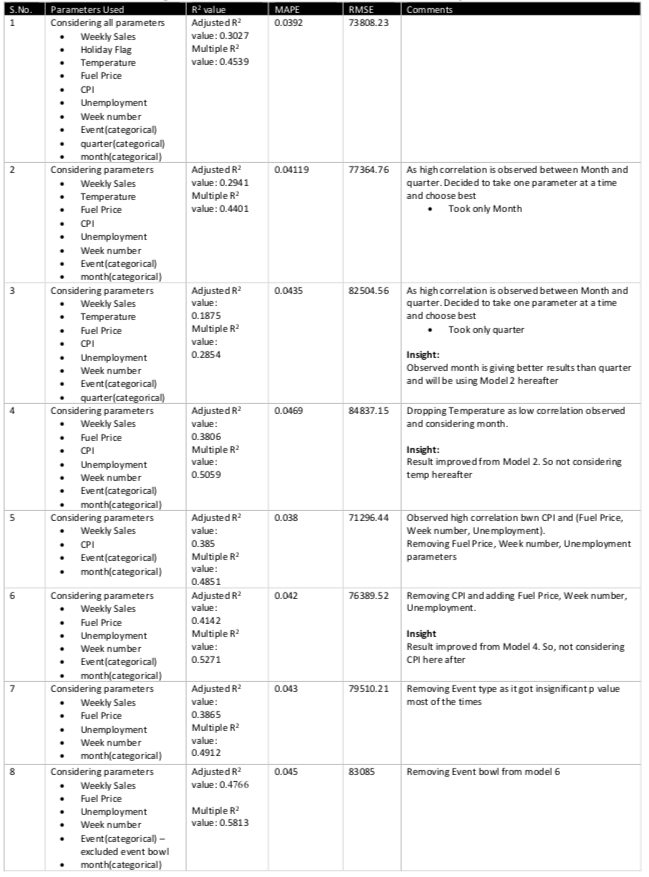

In [ ]:
############ Model- 8 ####################

#Considering parameters - Weekly Sales, Fuel Price, Week number, Unemployment,Event(categorical), month(categorical)
#removed Event bowl to Model 6 as it is causing NA's

# Splitting dataset into training set and test set
set.seed(123) # Seed initializes the randomness -- set.seed helps to fix randomness fixed everytime you open. you can write any number inside the set.seed()
library(caTools)

#Considering all parameters - Weekly Sales, Holiday FlagTemp, Fuel, CPI,Unemployment, Weeknumber, Event(categorical), quarter(categorical), month(categorical)
dataset <- data5[, c(1,4,6,7,11:12, 17:27 )]

#Creating a sample split and divided test & training sets in 30-70 ratio respectively
sample = sample.split(dataset, SplitRatio = 0.7) # Returns a vector with T for 70% of data
trainingSet = subset(dataset, sample == T)
testSet = subset(dataset, sample == F)

# Create model 
model = lm(formula = Weekly_Sales ~ . , data = trainingSet)
summary(model)

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)

# Visualizing train set results
y_pred_train = predict(model, newdata = trainingSet)
ggplot() + 
  geom_point(aes(x=trainingSet$Weekly_Sales,y=y_pred_train), size=3,colour = "Blue") +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_y_continuous(labels = label_number(suffix = " K", scale = 1e-3))+
  scale_x_continuous(labels = label_number(suffix = " K", scale = 1e-3))+
  ggtitle('Comparision of Actual Sales vs Predicted Sales - Train Data')+
  theme(plot.title = element_text(hjust = 0.5))+
  xlab("Actual Sales") + ylab("Predicted Sales")

# Visualizing the test set results
y_pred_test = predict(model, newdata = testSet)
ggplot() + 
  geom_point(aes(x=testSet$Weekly_Sales,y=y_pred_test), size =3, colour = "Blue") +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
  scale_y_continuous(labels = label_number(suffix = " K", scale = 1e-3))+
  scale_x_continuous(labels = label_number(suffix = " K", scale = 1e-3))+
  ggtitle('Comparision of Actual Sales vs Predicted Sales - Test Data')+
  theme(plot.title = element_text(hjust = 0.5))+
  xlab("Actual Sales") + ylab("Predicted Sales")

In [ ]:
### Parameters to validate the accuracy of the model and improvise.
MAPE(y_pred_test,testSet$Weekly_Sales)
RMSE(y_pred_test,testSet$Weekly_Sales)

In [ ]:
#checking multi collinearity
car::vif(model)

## **Insights:** ##
* ‘Model 8’ is the best model among all due to following reasons
    1. Relatively high R square value
    2. VIF values low indicating Less multi Collinearity
    3. Avoiding rank deficient error warnings caused by NA rows
    4. MAPE value which is in acceptable range
* Month can be considered as important independent variable for prediction as its p value are highly significant
* Fuel Price, Unemployment together can be considered as important factors than CPI alone.
* Model can be further improvised by
    1. Considering all Stores data for prediction
    2. Using Advanced models like Decision Trees, Random Forest
    3. Using K cross validation techniques for Sampling data

## **If you find it useful, upvote my code. Thanks for taking time to go through it. :)** ##